# 07 RAG Evaluation

**Full evaluation of the RAG pipeline.**

## What we measure?

| Metric | What it tests | Ideal |
|---|---|---|
| **Faithfulness** | Is the answer grounded in retrieved context? (no hallucinations) | > 0.85 |
| **Answer Relevancy** | Does the answer actually address the question? | > 0.80 |
| **Context Precision** | Are the retrieved chunks relevant? (retrieval quality) | > 0.75 |
| **Context Recall** | Does the context contain the needed information? | > 0.70 |

## Test set design

30 questions across all major use cases:
- Nutrition (protein, calories, macros, supplements)
- Training (volume, frequency, progressive overload, exercise selection)
- Program design (beginner/intermediate/advanced)
- Body composition (bulk/cut/recomp thresholds)
- Recovery (sleep, deload, fatigue)
- Case study style (program examples)

Each question has a **ground truth answer** derived from Henselmans course material - used by RAGAS to score faithfulness and recall.

In [1]:
import json, os, time
from pathlib import Path
from datetime import datetime
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import faiss
import matplotlib.pyplot as plt

from openai import OpenAI
from dotenv import load_dotenv
from tenacity import retry, wait_exponential, stop_after_attempt
load_dotenv(override=True)

NOTEBOOK_DIR = Path().resolve()
BACKEND_DIR = NOTEBOOK_DIR.parent
VS_DIR = BACKEND_DIR / 'data' / 'vectorstore'
PROCESSED_DIR = BACKEND_DIR / 'data' / 'processed'
EVAL_DIR = PROCESSED_DIR / 'evaluation'
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')
EVAL_DIR.mkdir(parents=True, exist_ok=True)
EMBEDDING_MODEL = os.getenv('EMBEDDING_MODEL')
LLM_MODEL = os.getenv('PRIMARY_MODEL')

openai_client = OpenAI(api_key=OPENAI_API_KEY)
EMBED_DIM = 3072

print('Setup complete')

Setup complete


## 1. Load Pipeline Components

In [2]:
index = faiss.read_index(str(VS_DIR / 'henselmans_openai.index'))
metadata = json.loads((VS_DIR / 'henselmans_openai_metadata.json').read_text(encoding='utf-8'))
assert index.ntotal == len(metadata)
print(f'FAISS: {index.ntotal:,} vectors | Metadata: {len(metadata):,} records')

# Core pipeline functions
@retry(wait=wait_exponential(min=1, max=20), stop=stop_after_attempt(3))
def rewrite_query(question: str, history: list = []) -> str:
    prompt = f"""User question: {question}
Rewrite as a SHORT English search query (5-10 words) for a fitness science knowledge base (Henselmans PTC course).
Reply ONLY with the search query, nothing else."""
    r = openai_client.chat.completions.create(
        model=LLM_MODEL,
        messages=[{'role': 'user', 'content': prompt}],
        temperature=0.0, max_tokens=30,
    )
    return r.choices[0].message.content.strip().strip('"')

def embed_query(text: str) -> np.ndarray:
    r = openai_client.embeddings.create(model=EMBEDDING_MODEL, input=[text])
    emb = np.array(r.data[0].embedding, dtype='float32').reshape(1, -1)
    faiss.normalize_L2(emb)
    return emb

def retrieve_faiss(query: str, k: int = 20) -> list:
    q_emb = embed_query(query)
    scores, ids = index.search(q_emb, k)
    return [{**metadata[idx], 'score': float(s)} for s, idx in zip(scores[0], ids[0]) if idx != -1]

def dual_retrieve(original: str, rewritten: str, k: int = 20) -> list:
    seen = {}
    for r in retrieve_faiss(original, k) + retrieve_faiss(rewritten, k):
        cid = r['chunk_id']
        if cid not in seen or r['score'] > seen[cid]['score']:
            seen[cid] = r
    return sorted(seen.values(), key=lambda x: x['score'], reverse=True)

SYSTEM_PROMPT = """Ти си персонален фитнес треньор и нутриционист. Работиш изцяло по методологията на Menno Henselmans.

ПРАВИЛА - следвай ги стриктно:
1. Отговаряй ВИНАГИ на БЪЛГАРСКИ
2. Ползвай КИЛОГРАМИ и метри, никога pounds или inches
3. Бъди ДИРЕКТЕН и ПРАКТИЧЕН - давай конкретни числа и препоръки
4. НЕ изнасяй лекции и НЕ цитирай проучвания, ако не са поискани
5. Говори като треньор, не като учебник - просто, ясно, приложимо
6. Ако нещо не е покрито в контекста, кажи го честно
7. Адаптирай отговора спрямо нивото и целта на потребителя
8. Посочвай винаги имената на упражненията единствено и САМО на английски език
9. Задължително базирай всичките си отговори САМО на ресурсите от курса

Контекст от курса на Henselmans (използвай САМО тази информация за факти):
{context}"""

@retry(wait=wait_exponential(min=1, max=20), stop=stop_after_attempt(3))
def generate_answer(question: str, chunks: list, history: list = []) -> str:
    context = '\n\n'.join(f'[{c["source"]}]\n{c["text"]}' for c in chunks)
    messages = [{'role': 'system', 'content': SYSTEM_PROMPT.format(context=context)}]
    for msg in history:
        messages.append({'role': msg['role'], 'content': msg['content']})
    messages.append({'role': 'user', 'content': question})
    r = openai_client.chat.completions.create(
        model=LLM_MODEL, messages=messages, temperature=0.4, max_tokens=1200,
    )
    return r.choices[0].message.content

def ask(question: str, history: list = [], filter_meta: dict = None) -> tuple:
    rewritten = rewrite_query(question, history)
    candidates = dual_retrieve(question, rewritten)
    if filter_meta:
        filtered = [c for c in candidates if all(c.get(k)==v for k,v in filter_meta.items())]
        candidates = filtered or candidates
    top_chunks = candidates[:5]
    answer = generate_answer(question, top_chunks, history)
    return answer, top_chunks

print('Pipeline loaded OK')

def mmr_diversity(candidates: list, top_n: int = 7, lambda_: float = 0.6) -> list:
    """MMR: balance relevance vs source diversity. Prevents all chunks from same file."""
    if len(candidates) <= top_n:
        return candidates
    selected, remaining = [candidates[0]], candidates[1:]
    while len(selected) < top_n and remaining:
        best_score, best_idx = -999, 0
        for j, cand in enumerate(remaining):
            relevance = cand['score']
            same_src = sum(1 for s in selected if s['source'] == cand['source'])
            mmr = lambda_ * relevance - (1 - lambda_) * same_src * 0.15
            if mmr > best_score:
                best_score, best_idx = mmr, j
        selected.append(remaining.pop(best_idx))
    return selected

FAISS: 6,077 vectors | Metadata: 6,077 records
Pipeline loaded OK


## 2. Test Dataset - 30 Questions with Ground Truth

In [3]:
# Ground truth answers are concise, factual statements derived from
# Henselmans PTC course material. Used by RAGAS to score faithfulness & recall.

TEST_DATASET = [
    # NUTRITION (8 questions)
    {
        'id': 'N01', 'category': 'nutrition', 'level': 'all', 'goal': 'cut',
        'question': 'Колко протеин трябва да приемам докато съм на дефицит?',
        'ground_truth': 'При дефицит Henselmans препоръчва 2.0-2.2 грама протеин на килограм телесно тегло, за да се запази мускулната маса. Приемът трябва да е разпределен в 3-5 хранения дневно, всяко с поне 0.4 грама протеин на килограм.',
    },
    {
        'id': 'N02', 'category': 'nutrition', 'level': 'all', 'goal': 'bulk',
        'question': 'Какъв калориен излишък е оптимален за чисто качване на мускули?',
        'ground_truth': 'За чисто качване Henselmans препоръчва умерен излишък от около 200-250 калории над TDEE. По-голям излишък води до непропорционално натрупване на мазнини без допълнителен мускулен растеж.',
    },
    {
        'id': 'N03', 'category': 'nutrition', 'level': 'all', 'goal': 'all',
        'question': 'Как се изчислява TDEE по метода на Henselmans?',
        'ground_truth': 'TDEE се изчислява чрез BMR по формулата на Katch-McArdle (370 + 21.6 x LBM в кг), умножен по коефициент на активност (1.2-1.9), плюс корекция за тренировъчните дни. Формулата използва чистата мускулна маса вместо общото тегло за по-точен резултат.',
    },
    {
        'id': 'N04', 'category': 'nutrition', 'level': 'all', 'goal': 'all',
        'question': 'Какво е значението на креатина и как да го приемам?',
        'ground_truth': 'Креатин монохидрат е най-добре изследваният ергогенен суплемент. Препоръчителната доза е 3-5 грама дневно. Не е нужна фаза на насищане. Подобрява представянето при високо-интензивни упражнения и може да увеличи мускулния растеж при съпротивително тренировъчно.',
    },
    {
        'id': 'N05', 'category': 'nutrition', 'level': 'all', 'goal': 'all',
        'question': 'Колко мазнини трябва да приемам минимум?',
        'ground_truth': 'Henselmans препоръчва минимум 0.8 грама мазнини на килограм телесно тегло за поддържане на хормоналното здраве. Отиването под този праг може да наруши тестостероновите нива и общото здраве.',
    },
    {
        'id': 'N06', 'category': 'nutrition', 'level': 'all', 'goal': 'all',
        'question': 'Важно ли е времето на хранене около тренировката?',
        'ground_truth': 'Времето на хранене има по-малко значение от общия дневен прием. Въглехидратите около тренировката могат да оптимизират представянето и възстановяването, но общата дневна консумация е по-важна от точното тайминг за повечето хора.',
    },
    {
        'id': 'N07', 'category': 'nutrition', 'level': 'all', 'goal': 'cut',
        'question': 'Какъв дефицит да направя за 0.5 кг загуба на мазнини на седмица?',
        'ground_truth': 'За загуба от 0.5 кг мазнини на седмица е нужен дефицит от около 500 калории на ден (3500 калории на седмица). При дефицит трябва да се увери, че протеинът е достатъчен (2.0-2.2 г/кг) за запазване на мускулната маса.',
    },
    {
        'id': 'N08', 'category': 'nutrition', 'level': 'all', 'goal': 'all',
        'question': 'Колко хранения на ден са оптимални за синтез на мускулен протеин?',
        'ground_truth': 'Henselmans препоръчва 3-5 хранения дневно с равномерно разпределение на протеина. Всяко хранене трябва да съдържа 0.4-0.55 грама протеин на килограм телесно тегло за максимален анаболен отговор.',
    },

    # TRAINING (8 questions)
    {
        'id': 'T01', 'category': 'training', 'level': 'all', 'goal': 'all',
        'question': 'Колко серии на седмица са оптимални за мускулна група при начинаещ?',
        'ground_truth': 'За начинаещи Henselmans препоръчва около 10 серии на седмица за основните мускулни групи. Това е близо до MEV (Minimum Effective Volume). Обемът трябва постепенно да се увеличава с времето към MAV.',
    },
    {
        'id': 'T02', 'category': 'training', 'level': 'all', 'goal': 'all',
        'question': 'Колко пъти в седмицата трябва да тренирам всяка мускулна група?',
        'ground_truth': 'Изследванията показват, че трениране на мускулна група 2 пъти седмично е оптимално за хипертрофия в сравнение с 1 път. При напреднали с голям обем, честотата от 3 пъти може да е по-добра за управление на обема.',
    },
    {
        'id': 'T03', 'category': 'training', 'level': 'all', 'goal': 'all',
        'question': 'В какъв диапазон на повторения трябва да тренирам за максимална хипертрофия?',
        'ground_truth': 'Хипертрофията може да се постигне в широк диапазон от повторения (5-30), стига сетовете да са близо до отказ. Традиционният диапазон от 8-12 повторения остава ефективен, но не е единственият правилен вариант.',
    },
    {
        'id': 'T04', 'category': 'training', 'level': 'all', 'goal': 'all',
        'question': 'Колко трябва да почивам между сериите за хипертрофия?',
        'ground_truth': 'За хипертрофия почивките от 2-3 минути между сериите са оптимални. По-кратките почивки (под 60 секунди) компрометират представянето и намаляват общия тренировъчен обем, което води до по-малко мускулен растеж.',
    },
    {
        'id': 'T05', 'category': 'training', 'level': 'all', 'goal': 'all',
        'question': 'Какво е прогресивно претоварване и как да го прилагам?',
        'ground_truth': 'Прогресивното претоварване е систематично увеличаване на стимула върху мускула за стимулиране на адаптация. Може да се постигне чрез добавяне на тегло, повторения, серии или подобряване на техниката. Това е основният механизъм за дългосрочен мускулен растеж.',
    },
    {
        'id': 'T06', 'category': 'training', 'level': 'intermediate', 'goal': 'all',
        'question': 'Кога трябва да направя deload и как?',
        'ground_truth': 'Deload се препоръчва след всеки 4-8 седмици прогресивно натоварване. При deload обемът се намалява с 40-60% при запазен интензитет. Това намалява натрупаната умора, намалява риска от нараняване и водо до подобрение в представянето след deload-а.',
    },
    {
        'id': 'T07', 'category': 'training', 'level': 'all', 'goal': 'all',
        'question': 'По-добри ли са съставните упражнения от изолацията за мускулен растеж?',
        'ground_truth': 'Съставните упражнения формират основата на всяка програма за хипертрофия. Изолационните упражнения допълват съставните, като насочват специфични мускули с по-голяма прецизност. Комбинацията от двете е оптимална стратегия.',
    },
    {
        'id': 'T08', 'category': 'training', 'level': 'advanced', 'goal': 'all',
        'question': 'Какво е MEV, MAV и MRV в тренировъчния обем?',
        'ground_truth': 'MEV (Minimum Effective Volume) е минималният обем за поддържане на мускул. MAV (Maximum Adaptive Volume) е оптималният обем за растеж. MRV (Maximum Recoverable Volume) е максималният обем, от който може да се възстановите. Програмите трябва да стартират близо до MEV и да се строят към MAV.',
    },

    # PROGRAM DESIGN (6 questions)
    {
        'id': 'P01', 'category': 'program_design', 'level': 'novice', 'goal': 'all',
        'question': 'Каква тренировъчна програма е подходяща за начинаещ, 3 пъти седмично?',
        'ground_truth': 'За начинаещи Full Body програмата 3 пъти седмично е оптималният избор. Всяка тренировка включва основните съставни движения (клек, мъртва тяга, лежанка, гребане). Обемът е нисък (2-3 серии на упражнение) с фокус върху техника и прогресия.',
    },
    {
        'id': 'P02', 'category': 'program_design', 'level': 'intermediate', 'goal': 'all',
        'question': 'Upper/Lower split подходящ ли е за напреднал начинаещ?',
        'ground_truth': 'Upper/Lower split е отличен избор за напреднал начинаещ или ранен intermediate. Тренировките 4 пъти седмично позволяват достатъчна честота (2x/седмица) и обем за хипертрофия, с добро управление на умората.',
    },
    {
        'id': 'P03', 'category': 'program_design', 'level': 'all', 'goal': 'all',
        'question': 'Как изглежда правилно попълнена intake форма по Henselmans?',
        'ground_truth': 'Intake формата на Henselmans включва: антропометрия (тегло, височина, възраст, пол), цел (bulk/cut/maintain), активност извън фитнеса, тренировъчна история и ниво, текущи вдигани тежести, предпочитания, наранявания и налично оборудване.',
    },
    {
        'id': 'P04', 'category': 'program_design', 'level': 'all', 'goal': 'cut',
        'question': 'Трябва ли да намаля обема по време на дефицит?',
        'ground_truth': 'По принцип обемът не трябва да се намалява значително при дефицит. Поддържането на тренировъчния стимул е критично за запазване на мускулната маса. При агресивен дефицит може да се наложи леко намаляване на обема, но интензитетът трябва да се запази.',
    },
    {
        'id': 'P05', 'category': 'program_design', 'level': 'advanced', 'goal': 'all',
        'question': 'Как се строи Push Pull Legs програма за напреднал?',
        'ground_truth': 'PPL за напреднал включва 6 тренировки седмично (2 цикъла Push/Pull/Legs). Push: гърди, рамена, трицепс. Pull: гръб, бицепс, задни делтоиди. Legs: квадрицепси, задни бедра, глутеуси. Обемът е висок (16-20 серии/мускулна група/седмица).',
    },
    {
        'id': 'P06', 'category': 'program_design', 'level': 'all', 'goal': 'all',
        'question': 'Как да определя тренировъчния си статус - начинаещ, intermediate или напреднал?',
        'ground_truth': 'Тренировъчният статус се определя по опит и постижения. Начинаещ: под 1 година последователно тренировъчно, прогресира на всяка тренировка. Intermediate: 1-3 години, прогресира седмично. Напреднал: 3+ години, прогресира месечно или по-бавно.',
    },

    # BODY COMPOSITION (4 questions)
    {
        'id': 'B01', 'category': 'body_composition', 'level': 'all', 'goal': 'all',
        'question': 'Аз съм мъж, при какъв процент мазнини трябва да започна да свалям вместо да качвам?',
        'ground_truth': 'Henselmans препоръчва мъже да минат на дефицит когато процентът мазнини надхвърли 15-16%. Над този праг инсулиновата чувствителност намалява и партиционирането на хранителните вещества се влошава, което прави качването неефективно.',
    },
    {
        'id': 'B02', 'category': 'body_composition', 'level': 'all', 'goal': 'maintain',
        'question': 'Възможно ли е едновременно да се губят мазнини и качват мускули?',
        'ground_truth': 'Рекомпозицията (едновременна загуба на мазнини и качване на мускули) е постижима, особено при начинаещи, хора след пауза или тези с по-висок процент мазнини. Изисква достатъчен протеин, около поддържащи калории и последователни съпротивителни тренировки.',
    },
    {
        'id': 'B03', 'category': 'body_composition', 'level': 'all', 'goal': 'all',
        'question': 'Как визуалната оценка на мазнините помага при планиране на програмата?',
        'ground_truth': 'Визуалната оценка на процента мазнини (чрез снимки front/back/side) позволява правилното определяне на целта - bulk или cut. Сравнение с референтни снимки по процент мазнини дава достатъчно точна оценка за практически цели, без нужда от скъпо оборудване.',
    },
    {
        'id': 'B04', 'category': 'body_composition', 'level': 'all', 'goal': 'all',
        'question': 'Какво е мускулна памет и как влияе на тренировъчното планиране?',
        'ground_truth': 'Мускулната памет позволява бързо възстановяване на изгубена мускулна маса след пауза от тренировки. Дължи се на запазването на миоядрата в мускулните влакна дори след атрофия. Хора, завърнали се след пауза, напредват много по-бързо от истински начинаещи.',
    },

    # RECOVERY (4 questions)
    {
        'id': 'R01', 'category': 'recovery', 'level': 'all', 'goal': 'all',
        'question': 'Колко часа сън са необходими за оптимално мускулно възстановяване?',
        'ground_truth': '7-9 часа сън на нощ са критични за оптимално мускулно възстановяване и растеж. По време на дълбокия сън пиковата секреция на растежен хормон, синтезът на протеин и процесите на мускулна репарация са най-активни.',
    },
    {
        'id': 'R02', 'category': 'recovery', 'level': 'all', 'goal': 'all',
        'question': 'Как стресът влияе на мускулния растеж и как да го управлявам?',
        'ground_truth': 'Хроничният психологически стрес повишава кортизола, което може да наруши мускулния протеинов синтез, да увеличи разграждането на протеин и да влоши качеството на съня. Управлението на стреса е легитимна компонента на всяка сериозна тренировъчна програма.',
    },
    {
        'id': 'R03', 'category': 'recovery', 'level': 'all', 'goal': 'all',
        'question': 'Полезно ли е активното възстановяване в почивните дни?',
        'ground_truth': 'Лека аеробна активност (ходене, колоездене с нисък интензитет) в почивните дни подобрява кръвотока, намалява DOMS и ускорява отстраняването на метаболитните странични продукти, без да добавя значителен тренировъчен стрес.',
    },
    {
        'id': 'R04', 'category': 'recovery', 'level': 'intermediate', 'goal': 'all',
        'question': 'Как да разпозная признаците на претрениране?',
        'ground_truth': 'Признаците на претрениране включват: постоянна умора, намалено представяне, влошено настроение, нарушен сън, загуба на апетит и повишена честота на заболявания. При тези симптоми е нужен структуриран deload или пълна почивка.',
    },
]

print(f'Test dataset ready: {len(TEST_DATASET)} questions')
from collections import Counter
cats = Counter(q['category'] for q in TEST_DATASET)
for cat, n in cats.most_common():
    print(f'  {cat:<20}: {n}')

Test dataset ready: 30 questions
  nutrition           : 8
  training            : 8
  program_design      : 6
  body_composition    : 4
  recovery            : 4


## 3. Run Pipeline on All Test Questions

In [4]:
print('Running RAG pipeline on all test questions...')
print(f'This will make ~{len(TEST_DATASET) * 3} OpenAI API calls\n')

results = []

for i, item in enumerate(TEST_DATASET):
    qid = item['id']
    question = item['question']

    try:
        answer, chunks = ask(question)
        contexts = [c['text'] for c in chunks]
        sources = [c['source'] for c in chunks]
        scores = [c['score'] for c in chunks]

        results.append({
            'id': qid,
            'category': item['category'],
            'level': item['level'],
            'goal': item['goal'],
            'question': question,
            'ground_truth': item['ground_truth'],
            'answer': answer,
            'contexts': contexts,
            'sources': sources,
            'scores': scores,
            'error': None,
        })
        print(f'  [{i+1:02d}/30] {qid} OK - top chunk score: {scores[0]:.4f}')

    except Exception as e:
        results.append({'id': qid, 'question': question, 'error': str(e)})
        print(f'  [{i+1:02d}/30] {qid} ERROR: {e}')

    time.sleep(0.5)  # gentle rate limiting

ok = [r for r in results if not r.get('error')]
errors = [r for r in results if r.get('error')]
print(f'\nCompleted: {len(ok)}/30 OK | {len(errors)} errors')

Running RAG pipeline on all test questions...
This will make ~90 OpenAI API calls

  [01/30] N01 OK - top chunk score: 0.7014
  [02/30] N02 OK - top chunk score: 0.5816
  [03/30] N03 OK - top chunk score: 0.6305
  [04/30] N04 OK - top chunk score: 0.6334
  [05/30] N05 OK - top chunk score: 0.6238
  [06/30] N06 OK - top chunk score: 0.6006
  [07/30] N07 OK - top chunk score: 0.5871
  [08/30] N08 OK - top chunk score: 0.6879
  [09/30] T01 OK - top chunk score: 0.6904
  [10/30] T02 OK - top chunk score: 0.7120
  [11/30] T03 OK - top chunk score: 0.6241
  [12/30] T04 OK - top chunk score: 0.5971
  [13/30] T05 OK - top chunk score: 0.6554
  [14/30] T06 OK - top chunk score: 0.6668
  [15/30] T07 OK - top chunk score: 0.7776
  [16/30] T08 OK - top chunk score: 0.5529
  [17/30] P01 OK - top chunk score: 0.5245
  [18/30] P02 OK - top chunk score: 0.5222
  [19/30] P03 OK - top chunk score: 0.7027
  [20/30] P04 OK - top chunk score: 0.5869
  [21/30] P05 OK - top chunk score: 0.5863
  [22/30] P06 

## 4. RAGAS-style Metrics (LLM-as-judge)

In [5]:
# We implement RAGAS metrics using gpt-4o-mini as the judge.
# This avoids the RAGAS library dependency while giving the same quality.

@retry(wait=wait_exponential(min=1, max=20), stop=stop_after_attempt(3))
def score_faithfulness(question: str, answer: str, contexts: list[str]) -> float:
    """
    Faithfulness: what fraction of claims in the answer are supported by the context?
    Score: 0.0 - 1.0
    """
    context_text = '\n---\n'.join(contexts)
    prompt = f"""You are evaluating a RAG system. 
    
Question: {question}

Retrieved context:
{context_text}

Generated answer:
{answer}

TASK: Identify each factual claim in the answer. For each claim, determine if it is 
directly supported by the retrieved context above (not general knowledge).

Return a JSON object with:
- "supported_claims": list of claims that ARE supported by context
- "unsupported_claims": list of claims that are NOT in the context (potential hallucinations)
- "score": float 0.0-1.0 (supported / total claims)

Reply ONLY with valid JSON."""

    r = openai_client.chat.completions.create(
        model=LLM_MODEL,
        messages=[{'role': 'user', 'content': prompt}],
        response_format={'type': 'json_object'},
        temperature=0.0, max_tokens=500,
    )
    data = json.loads(r.choices[0].message.content)
    return float(data.get('score', 0.0))


@retry(wait=wait_exponential(min=1, max=20), stop=stop_after_attempt(3))
def score_answer_relevancy(question: str, answer: str) -> float:
    """
    Answer Relevancy: does the answer actually address the question?
    Score: 0.0 - 1.0
    """
    prompt = f"""Evaluate how relevant this answer is to the question.

Question: {question}
Answer: {answer}

Score from 0.0 to 1.0:
- 1.0: Answer directly and completely addresses the question
- 0.7: Answer mostly addresses the question with minor gaps
- 0.5: Answer partially addresses the question
- 0.3: Answer is tangentially related
- 0.0: Answer does not address the question at all

Return JSON: {{"score": float, "reason": "brief explanation"}}
Reply ONLY with valid JSON."""

    r = openai_client.chat.completions.create(
        model=LLM_MODEL,
        messages=[{'role': 'user', 'content': prompt}],
        response_format={'type': 'json_object'},
        temperature=0.0, max_tokens=200,
    )
    data = json.loads(r.choices[0].message.content)
    return float(data.get('score', 0.0))


@retry(wait=wait_exponential(min=1, max=20), stop=stop_after_attempt(3))
def score_context_precision(question: str, contexts: list[str]) -> float:
    """
    Context Precision: what fraction of retrieved chunks are relevant to the question?
    Score: 0.0 - 1.0
    """
    prompt = f"""Evaluate the relevance of each retrieved context chunk to the question.

Question: {question}

Retrieved chunks:
{chr(10).join(f'Chunk {i+1}: {ctx[:300]}' for i, ctx in enumerate(contexts))}

For each chunk, rate relevance: 1 (relevant) or 0 (not relevant).
Return JSON: {{"chunk_scores": [1, 0, 1, ...], "score": float (mean of scores)}}
Reply ONLY with valid JSON."""

    r = openai_client.chat.completions.create(
        model=LLM_MODEL,
        messages=[{'role': 'user', 'content': prompt}],
        response_format={'type': 'json_object'},
        temperature=0.0, max_tokens=200,
    )
    data = json.loads(r.choices[0].message.content)
    scores = data.get('chunk_scores', [])
    return float(np.mean(scores)) if scores else 0.0


@retry(wait=wait_exponential(min=1, max=20), stop=stop_after_attempt(3))
def score_context_recall(question: str, ground_truth: str, contexts: list[str]) -> float:
    """
    Context Recall: does the context contain the information needed to answer correctly?
    Uses semantic matching - not exact string match.
    Score: 0.0 - 1.0
    """
    context_text = "\n---\n".join(contexts)
    prompt = f"""You are evaluating a RAG retrieval system.

Question: {question}
Ground truth answer (reference): {ground_truth}
Retrieved context: {context_text[:2000]}

Task: Identify the KEY FACTUAL CLAIMS in the ground truth answer.
Then check: for each key claim, is the SEMANTIC MEANING present in the retrieved context?
Do NOT require exact wording - paraphrases and related concepts count.

Examples of semantic matches:
- Ground truth says "2.0-2.2 g/kg" - context says "1.6 to 2.2 grams per kg" → MATCH
- Ground truth says "3-5 meals" - context says "multiple meals throughout the day" → PARTIAL
- Ground truth says "7-9 hours sleep" - context says "adequate sleep is important" → NO MATCH (too vague)

Return JSON:
{{
  "key_claims": ["claim1", "claim2", ...],
  "claims_found": ["claim1", ...],
  "claims_missing": ["claim2", ...],
  "score": 0.0-1.0
}}
Reply ONLY with valid JSON."""

    r = openai_client.chat.completions.create(
        model=LLM_MODEL,
        messages=[{"role": "user", "content": prompt}],
        response_format={"type": "json_object"},
        temperature=0.0, max_tokens=500,
    )
    data = json.loads(r.choices[0].message.content)
    return float(data.get("score", 0.0))


print('Scoring functions defined')
print('Metrics: faithfulness, answer_relevancy, context_precision, context_recall')

Scoring functions defined
Metrics: faithfulness, answer_relevancy, context_precision, context_recall


In [6]:
print('Scoring all results (4 metrics x 30 questions = 120 LLM calls)...\n')

for i, r in enumerate(ok):
    try:
        r['faithfulness'] = score_faithfulness(r['question'], r['answer'], r['contexts'])
        r['answer_relevancy'] = score_answer_relevancy(r['question'], r['answer'])
        r['context_precision'] = score_context_precision(r['question'], r['contexts'])
        r['context_recall'] = score_context_recall(r['question'], r['ground_truth'], r['contexts'])
        r['ragas_score'] = np.mean([r['faithfulness'], r['answer_relevancy'],
                                           r['context_precision'], r['context_recall']])
        print(f'  [{i+1:02d}/30] {r["id"]} | '
              f'F={r["faithfulness"]:.2f} AR={r["answer_relevancy"]:.2f} '
              f'CP={r["context_precision"]:.2f} CR={r["context_recall"]:.2f} '
              f'→ {r["ragas_score"]:.2f}')
    except Exception as e:
        r['faithfulness'] = r['answer_relevancy'] = r['context_precision'] = r['context_recall'] = 0.0
        r['ragas_score']  = 0.0
        print(f'  [{i+1:02d}/30] {r["id"]} SCORE ERROR: {e}')
    time.sleep(0.3)

print('\nScoring complete')

Scoring all results (4 metrics x 30 questions = 120 LLM calls)...

  [01/30] N01 | F=0.00 AR=1.00 CP=0.80 CR=0.00 → 0.45
  [02/30] N02 | F=0.67 AR=1.00 CP=0.60 CR=0.50 → 0.69
  [03/30] N03 | F=1.00 AR=1.00 CP=0.80 CR=0.80 → 0.90
  [04/30] N04 | F=1.00 AR=1.00 CP=0.80 CR=0.60 → 0.85
  [05/30] N05 | F=1.00 AR=0.70 CP=0.80 CR=0.00 → 0.62
  [06/30] N06 | F=1.00 AR=1.00 CP=0.60 CR=0.67 → 0.82
  [07/30] N07 | F=0.33 AR=0.70 CP=0.80 CR=0.00 → 0.46
  [08/30] N08 | F=1.00 AR=0.70 CP=0.60 CR=0.50 → 0.70
  [09/30] T01 | F=0.67 AR=1.00 CP=0.80 CR=0.33 → 0.70
  [10/30] T02 | F=1.00 AR=1.00 CP=0.80 CR=1.00 → 0.95
  [11/30] T03 | F=0.67 AR=1.00 CP=0.80 CR=1.00 → 0.87
  [12/30] T04 | F=1.00 AR=1.00 CP=0.80 CR=0.75 → 0.89
  [13/30] T05 | F=0.71 AR=1.00 CP=0.60 CR=0.67 → 0.75
  [14/30] T06 | F=1.00 AR=1.00 CP=0.60 CR=0.80 → 0.85
  [15/30] T07 | F=0.83 AR=1.00 CP=0.80 CR=0.67 → 0.83
  [16/30] T08 | F=1.00 AR=1.00 CP=0.60 CR=0.00 → 0.65
  [17/30] P01 | F=0.33 AR=1.00 CP=0.40 CR=0.00 → 0.43
  [18/30] P02 |

## 5. Results Analysis

In [8]:
import statistics

metrics = ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall', 'ragas_score']

print('=' * 65)
print('  OVERALL RESULTS')
print('=' * 65)
for m in metrics:
    vals = [r[m] for r in ok if m in r]
    if vals:
        mean = statistics.mean(vals)
        sd = statistics.stdev(vals) if len(vals) > 1 else 0
        mn = min(vals)
        mx = max(vals)
        # Pass/fail threshold
        thresholds = {'faithfulness':0.85,'answer_relevancy':0.80,
                      'context_precision':0.75,'context_recall':0.70,'ragas_score':0.75}
        status = '✅ PASS' if mean >= thresholds.get(m, 0.75) else '⚠️  BELOW TARGET'
        print(f'  {m:<22}: {mean:.3f} ± {sd:.3f}  (min {mn:.2f} max {mx:.2f})  {status}')

print()
print('=' * 65)
print('  BY CATEGORY')
print('=' * 65)
from collections import defaultdict
cat_scores = defaultdict(list)
for r in ok:
    cat_scores[r['category']].append(r.get('ragas_score', 0))
for cat, scores in sorted(cat_scores.items()):
    print(f'  {cat:<22}: {statistics.mean(scores):.3f}  (n={len(scores)})')

print()
print('=' * 65)
print('  WORST 5 QUESTIONS (by RAGAS score)')
print('=' * 65)
worst = sorted(ok, key=lambda x: x.get('ragas_score', 0))[:5]
for r in worst:
    print(f'  [{r["ragas_score"]:.2f}] {r["id"]} — {r["question"][:60]}')
    print(f'         F={r["faithfulness"]:.2f} AR={r["answer_relevancy"]:.2f} '
          f'CP={r["context_precision"]:.2f} CR={r["context_recall"]:.2f}')

  OVERALL RESULTS
  faithfulness          : 0.815 ± 0.255  (min 0.00 max 1.00)  ⚠️  BELOW TARGET
  answer_relevancy      : 0.970 ± 0.092  (min 0.70 max 1.00)  ✅ PASS
  context_precision     : 0.687 ± 0.155  (min 0.20 max 1.00)  ⚠️  BELOW TARGET
  context_recall        : 0.474 ± 0.312  (min 0.00 max 1.00)  ⚠️  BELOW TARGET
  ragas_score           : 0.736 ± 0.143  (min 0.43 max 0.95)  ⚠️  BELOW TARGET

  BY CATEGORY
  body_composition      : 0.747  (n=4)
  nutrition             : 0.687  (n=8)
  program_design        : 0.694  (n=6)
  recovery              : 0.742  (n=4)
  training              : 0.809  (n=8)

  WORST 5 QUESTIONS (by RAGAS score)
  [0.43] P01 — Каква тренировъчна програма е подходяща за начинаещ, 3 пъти 
         F=0.33 AR=1.00 CP=0.40 CR=0.00
  [0.45] N01 — Колко протеин трябва да приемам докато съм на дефицит?
         F=0.00 AR=1.00 CP=0.80 CR=0.00
  [0.46] N07 — Какъв дефицит да направя за 0.5 кг загуба на мазнини на седм
         F=0.33 AR=0.70 CP=0.80 CR=0.00
  [0.53

## 6. Visualizations

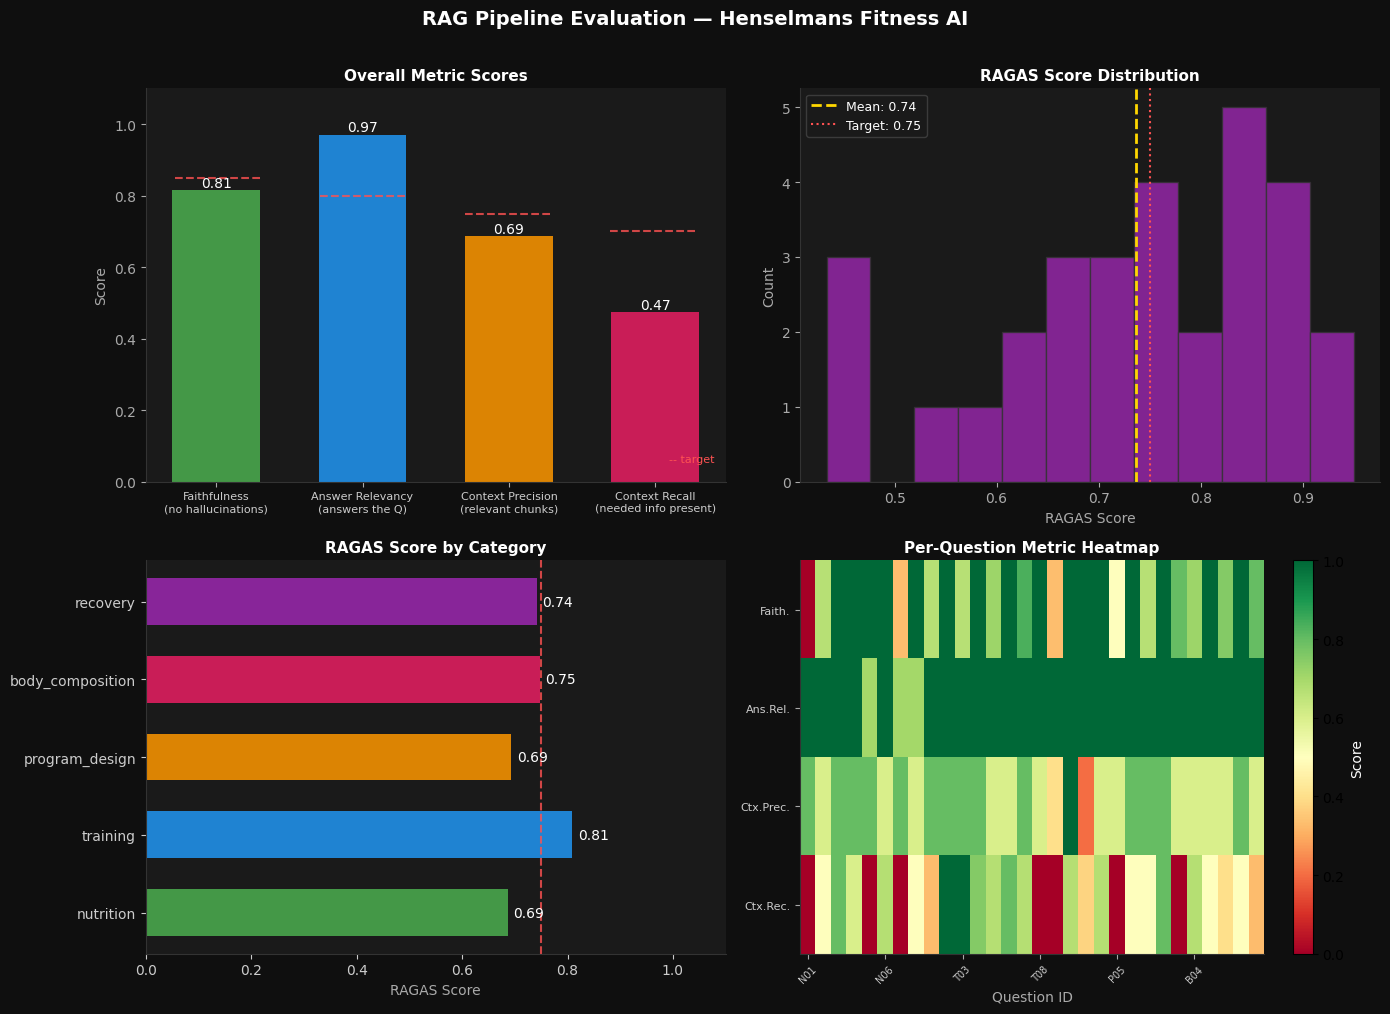

Visualization saved -> D:\Cybernetic Gym Assistant\backend\data\processed\evaluation\evaluation_results.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#0f0f0f')
fig.suptitle('RAG Pipeline Evaluation — Henselmans Fitness AI', 
             color='white', fontsize=14, fontweight='bold', y=1.01)

COLORS = ['#4CAF50','#2196F3','#FF9800','#E91E63','#9C27B0']
METRIC_LABELS = {
    'faithfulness': 'Faithfulness\n(no hallucinations)',
    'answer_relevancy': 'Answer Relevancy\n(answers the Q)',
    'context_precision': 'Context Precision\n(relevant chunks)',
    'context_recall': 'Context Recall\n(needed info present)',
}
TARGETS = {'faithfulness':0.85,'answer_relevancy':0.80,'context_precision':0.75,'context_recall':0.70}

def style(ax, title):
    ax.set_facecolor('#1a1a1a')
    ax.set_title(title, color='white', fontsize=11, fontweight='bold')
    ax.tick_params(colors='#aaa')
    ax.spines['bottom'].set_color('#333')
    ax.spines['left'].set_color('#333')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Plot 1: Overall metric bars
ax = axes[0, 0]
style(ax, 'Overall Metric Scores')
m_names = list(METRIC_LABELS.keys())
m_means = [statistics.mean([r[m] for r in ok if m in r]) for m in m_names]
m_labels = [METRIC_LABELS[m] for m in m_names]
bars = ax.bar(range(len(m_names)), m_means, color=COLORS[:4], alpha=0.85, width=0.6)
for i, (bar, tgt) in enumerate(zip(bars, [TARGETS[m] for m in m_names])):
    ax.axhline(tgt, xmin=i/len(m_names)+0.05, xmax=(i+1)/len(m_names)-0.05,
               color='#ff5252', linestyle='--', linewidth=1.5, alpha=0.8)
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.2f}', ha='center', color='white', fontsize=10)
ax.set_xticks(range(len(m_names)))
ax.set_xticklabels(m_labels, fontsize=8, color='#ccc')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', color='#aaa')
ax.text(0.98, 0.05, '-- target', transform=ax.transAxes, color='#ff5252', fontsize=8, ha='right')

# Plot 2: RAGAS score distribution
ax = axes[0, 1]
style(ax, 'RAGAS Score Distribution')
ragas_vals = [r.get('ragas_score', 0) for r in ok]
ax.hist(ragas_vals, bins=12, color='#9C27B0', alpha=0.8, edgecolor='#333')
ax.axvline(statistics.mean(ragas_vals), color='#FFD700', linestyle='--',
           linewidth=2, label=f'Mean: {statistics.mean(ragas_vals):.2f}')
ax.axvline(0.75, color='#ff5252', linestyle=':', linewidth=1.5, label='Target: 0.75')
ax.set_xlabel('RAGAS Score', color='#aaa')
ax.set_ylabel('Count', color='#aaa')
ax.legend(facecolor='#1a1a1a', edgecolor='#444', labelcolor='white', fontsize=9)

# Plot 3: Score by category
ax = axes[1, 0]
style(ax, 'RAGAS Score by Category')
cat_names  = list(cat_scores.keys())
cat_means  = [statistics.mean(cat_scores[c]) for c in cat_names]
cat_colors = COLORS[:len(cat_names)]
bars = ax.barh(cat_names, cat_means, color=cat_colors, alpha=0.85, height=0.6)
ax.axvline(0.75, color='#ff5252', linestyle='--', linewidth=1.5, alpha=0.8)
for bar in bars:
    ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.2f}', va='center', color='white', fontsize=10)
ax.set_xlim(0, 1.1)
ax.set_xlabel('RAGAS Score', color='#aaa')
ax.tick_params(colors='#ccc')

# Plot 4: Per-question scores heatmap
ax = axes[1, 1]
style(ax, 'Per-Question Metric Heatmap')
metric_keys = ['faithfulness','answer_relevancy','context_precision','context_recall']
heatmap_data = np.array([[r.get(m, 0) for m in metric_keys] for r in ok])
im = ax.imshow(heatmap_data.T, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_yticks(range(len(metric_keys)))
ax.set_yticklabels(['Faith.','Ans.Rel.','Ctx.Prec.','Ctx.Rec.'], color='#ccc', fontsize=8)
ax.set_xticks(range(0, len(ok), 5))
ax.set_xticklabels([ok[i]['id'] for i in range(0, len(ok), 5)], color='#ccc', fontsize=7, rotation=45)
ax.set_xlabel('Question ID', color='#aaa')
plt.colorbar(im, ax=ax, label='Score').ax.yaxis.label.set_color('white')

plt.tight_layout()
viz_path = EVAL_DIR / 'evaluation_results.png'
plt.savefig(str(viz_path), dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(f'Visualization saved -> {viz_path}')

## 7. Qualitative Analysis - Best & Worst Answers

In [11]:
print('BEST ANSWER (highest RAGAS score)')
print('=' * 65)
best = max(ok, key=lambda x: x.get('ragas_score', 0))
print(f'Q  : {best["question"]}')
print(f'Scores: F={best["faithfulness"]:.2f} AR={best["answer_relevancy"]:.2f} '
      f'CP={best["context_precision"]:.2f} CR={best["context_recall"]:.2f}')
print(f'\nAnswer:\n{best["answer"]}')
print()
print('WORST ANSWER (lowest RAGAS score)')
print('=' * 65)
worst_one = min(ok, key=lambda x: x.get('ragas_score', 0))
print(f'Q  : {worst_one["question"]}')
print(f'Scores: F={worst_one["faithfulness"]:.2f} AR={worst_one["answer_relevancy"]:.2f} '
      f'CP={worst_one["context_precision"]:.2f} CR={worst_one["context_recall"]:.2f}')
print(f'\nAnswer:\n{worst_one["answer"]}')
print(f'\nGround truth:\n{worst_one["ground_truth"]}')

BEST ANSWER (highest RAGAS score)
Q  : Колко пъти в седмицата трябва да тренирам всяка мускулна група?
Scores: F=1.00 AR=1.00 CP=0.80 CR=1.00

Answer:
Всяка мускулна група трябва да се тренира поне 2 пъти в седмицата. Ако обемът на тренировките за конкретната мускулна група надвишава 16 серии, е препоръчително да я тренираш поне 3 пъти в седмицата. Напредналите атлети, които натоварват мускулите си до лимита, могат да се възползват от тренировки на мускулите дори всеки ден или два пъти на ден.

WORST ANSWER (lowest RAGAS score)
Q  : Каква тренировъчна програма е подходяща за начинаещ, 3 пъти седмично?
Scores: F=0.33 AR=1.00 CP=0.40 CR=0.00

Answer:
За начинаещ, който иска да тренира 3 пъти седмично, ето една примерна тренировъчна програма:

### Програма за тренировки (3 пъти седмично)

**Ден 1: Горна част на тялото**
1. Bench Press: 4 sets x 8 reps
2. Bent Over Row: 4 sets x 8 reps
3. Overhead Press: 4 sets x 8 reps
4. Bicep Curls: 3 sets x 10 reps
5. Triceps Extensions: 3 sets x 10 re

## 8. Save Full Report

In [12]:
report = {
    'generated_at': datetime.now().isoformat(),
    'model_stack': {
        'embedding': 'text-embedding-3-large (3072d)',
        'llm': 'gpt-4o-mini',
        'retrieval': 'FAISS IndexFlatIP dual retrieve (k=20, top=5)',
    },
    'summary': {
        m: round(statistics.mean([r[m] for r in ok if m in r]), 4)
        for m in metrics
    },
    'by_category': {
        cat: round(statistics.mean(scores), 4)
        for cat, scores in cat_scores.items()
    },
    'questions': ok,
}

report_path = EVAL_DIR / 'evaluation_report.json'
report_path.write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding='utf-8')
print(f'Report saved -> {report_path}')

print()
print('=' * 65)
print('  NOTEBOOK 07 — EVALUATION COMPLETE')
print('=' * 65)
print()
for m in metrics:
    vals = [r[m] for r in ok if m in r]
    mean = statistics.mean(vals) if vals else 0
    thr  = {'faithfulness':0.85,'answer_relevancy':0.80,
             'context_precision':0.75,'context_recall':0.70,'ragas_score':0.75}
    status = 'PASS' if mean >= thr.get(m, 0.75) else 'NEEDS WORK'
    print(f'  {m:<22}: {mean:.3f}  [{status}]')

Report saved -> D:\Cybernetic Gym Assistant\backend\data\processed\evaluation\evaluation_report.json

  NOTEBOOK 07 — EVALUATION COMPLETE

  faithfulness          : 0.815  [NEEDS WORK]
  answer_relevancy      : 0.970  [PASS]
  context_precision     : 0.687  [NEEDS WORK]
  context_recall        : 0.474  [NEEDS WORK]
  ragas_score           : 0.736  [NEEDS WORK]
